# 🔬 Lab 2: Измерение акустического канала

**Цель**: Охарактеризовать канал «динамик → воздух → микрофон»: задержка, АЧХ, шум, многолучёвость.  
**Метод**: Симуляция физических эффектов + хуки для реальных измерений (`sounddevice`).

| Эксперимент | Что измеряем |
|---|---|
| 2.1 | Задержка канала (loopback) |
| 2.2 | Шумовой профиль (AWGN, розовый, «комнатный») |
| 2.3 | Импульсная характеристика и реверберация |
| 2.4 | АЧХ канала (затухание на частотах) |
| 2.5 | Затухание с расстоянием (~1/r²) |
| 2.6 | SNR vs расстояние — пределы режимов |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('common'))
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp
import modem_lib as m

plt.rcParams['figure.dpi'] = 110
FS = m.FS
rng = np.random.default_rng(3)
os.makedirs('results', exist_ok=True)

## 2.1 Задержка канала
В реальном канале есть задержка: буфер звуковой карты + распространение звука (~343 м/с → 2.9 мс/м).
Симулируем задержку и находим её кросс-корреляцией с chirp.

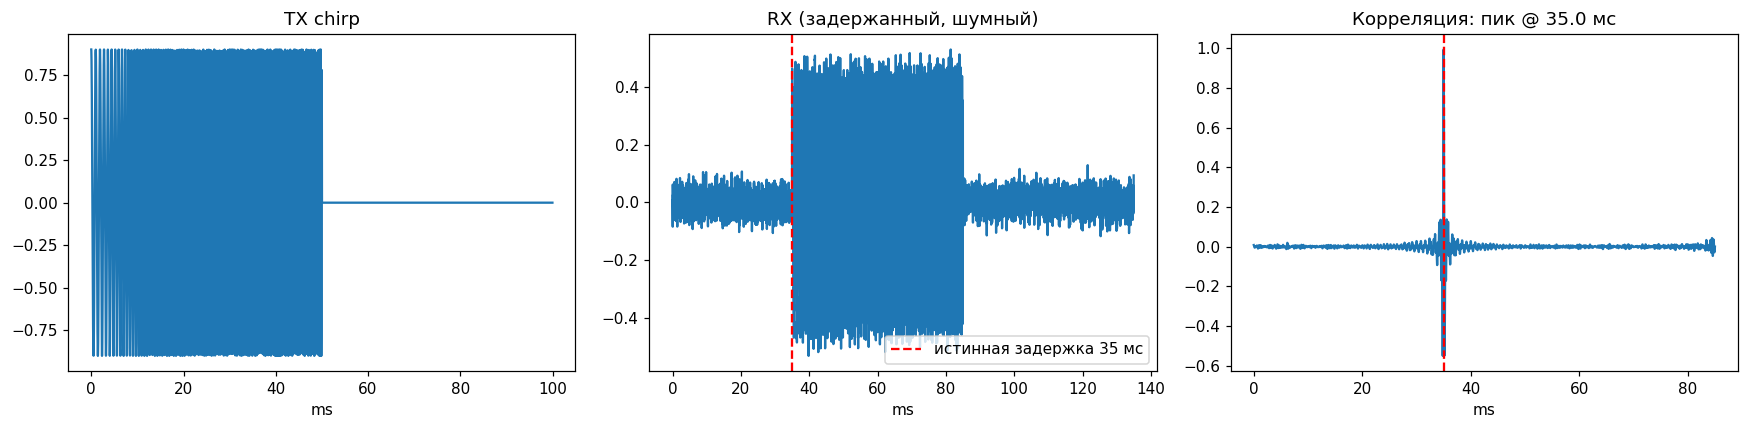

Измеренная задержка: 35.00 мс (истинная 35 мс), ошибка 0 сэмплов


In [2]:
chirp = m.generate_chirp(1000, 4000, 0.05)
# симуляция задержки: 5 м расстояния (~15 мс) + 20 мс буфер
delay_ms = 15 + 20
delay_n = int(FS * delay_ms / 1000)
tx = np.concatenate([chirp, m.generate_silence(0.05)])
rx = np.concatenate([np.zeros(delay_n, dtype=np.float32), tx]) * 0.5  # + затухание
rx = m.add_awgn(rx, snr_db=15, seed=2)

corr, peak, val = m.cross_correlate(rx, chirp)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(np.arange(len(tx))/FS*1000, tx); axes[0].set_title('TX chirp'); axes[0].set_xlabel('ms')
axes[1].plot(np.arange(len(rx))/FS*1000, rx); axes[1].axvline(delay_ms, color='r', ls='--', label=f'истинная задержка {delay_ms} мс')
axes[1].set_title('RX (задержанный, шумный)'); axes[1].set_xlabel('ms'); axes[1].legend()
axes[2].plot(np.arange(len(corr))/FS*1000, corr); axes[2].axvline(peak/FS*1000, color='r', ls='--')
axes[2].set_title(f'Корреляция: пик @ {peak/FS*1000:.1f} мс'); axes[2].set_xlabel('ms')
plt.tight_layout(); plt.show()
print(f'Измеренная задержка: {peak/FS*1000:.2f} мс (истинная {delay_ms} мс), ошибка {abs(peak-delay_n)} сэмплов')

## 2.2 Шумовой профиль
В комнате: низкочастотный гул (вентиляция, 50 Гц сеть), розовый шум, редкие всплески. Моделируем.

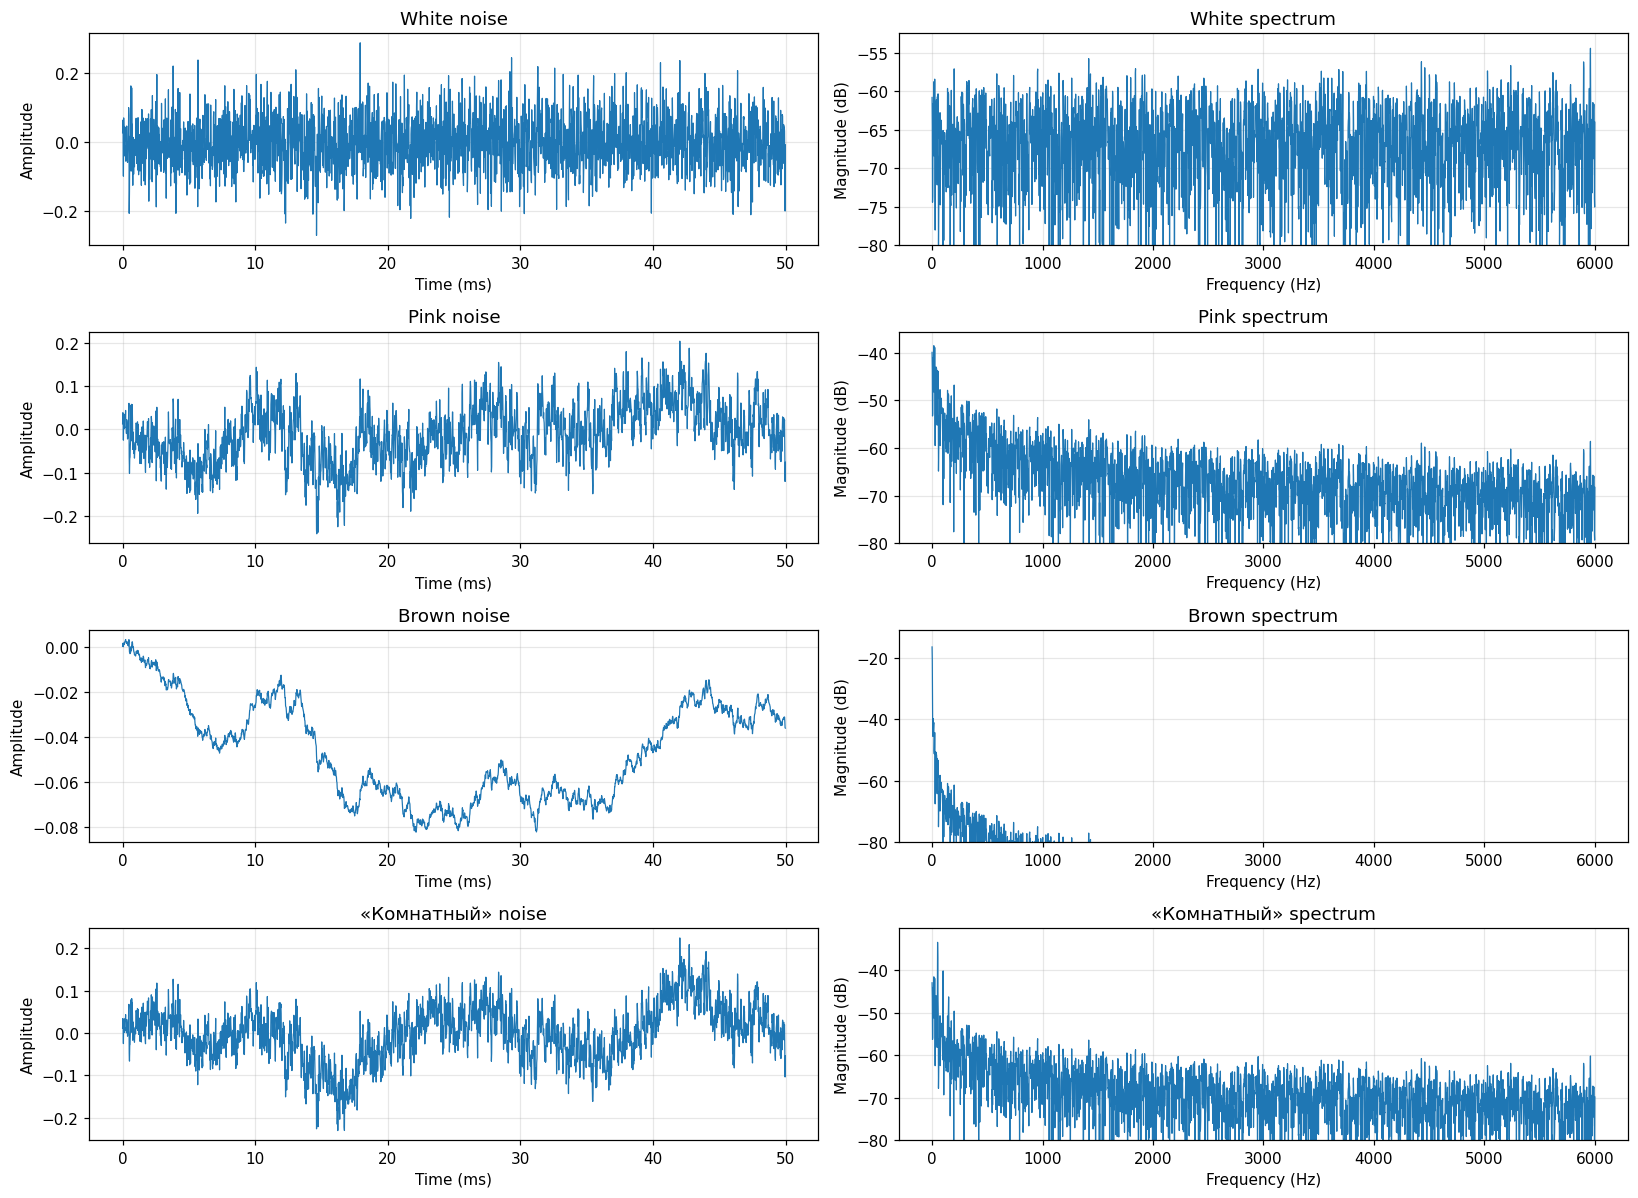

Розовый шум: -3 дБ/октава (равная энергия на октаву) — модель реальной комнаты.
Гул 50 Гц и гармоники — типичная помеха от сети. Наш модем работает на 1-4 кГц → выше гула.


In [3]:
dur = 0.5
white = m.generate_noise(dur, noise_type='white', amplitude=0.3, seed=1)
pink = m.generate_noise(dur, noise_type='pink', amplitude=0.3, seed=1)
brown = m.generate_noise(dur, noise_type='brown', amplitude=0.3, seed=1)
# «комнатный» шум: розовый + гул 50 Гц + гармоники
hum = sum(m.generate_tone(f, dur, amplitude=a) for f, a in [(50,0.05),(100,0.02),(150,0.01)])
room = pink*0.7 + hum + white*0.1

fig, axes = plt.subplots(4, 2, figsize=(15, 11))
for i,(s,name) in enumerate([(white,'White'),(pink,'Pink'),(brown,'Brown'),(room,'«Комнатный»')]):
    m.plot_waveform(s, ax=axes[i,0], title=f'{name} noise', max_duration=0.05)
    m.plot_spectrum(s, ax=axes[i,1], title=f'{name} spectrum', fmax=6000)
plt.tight_layout(); plt.show()
print('Розовый шум: -3 дБ/октава (равная энергия на октаву) — модель реальной комнаты.')
print('Гул 50 Гц и гармоники — типичная помеха от сети. Наш модем работает на 1-4 кГц → выше гула.')

## 2.3 Импульсная характеристика и многолучёвость
Звук отражается от стен → эхо. Модель: прямой луч + затухающие отражения. Оцениваем IR через деконволюцию chirp.

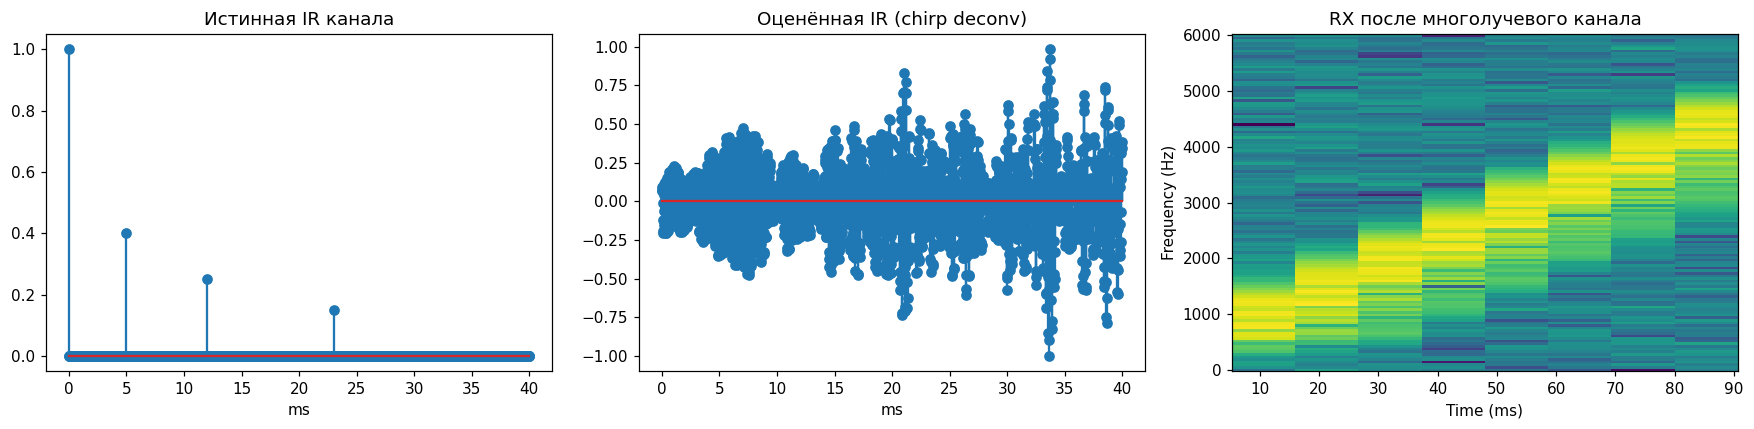

Видны 4 пика: прямой луч + 3 отражения. Отражения вызывают межсимвольную интерференцию (ISI).
Вывод для протокола: длительность символа должна быть > spread канала (~23 мс) ИЛИ нужна эквализация/CP в OFDM.


In [4]:
# Модель канала: прямой луч + 3 отражения
ir_true = np.zeros(int(0.04*FS)); ir_true[0]=1.0
for d_ms, g in [(5,0.4),(12,0.25),(23,0.15)]:
    ir_true[int(d_ms/1000*FS)] = g
chirp_long = m.generate_chirp(500, 5000, 0.1)
rx_ch = sp.fftconvolve(chirp_long, ir_true)[:len(chirp_long)]
rx_ch = m.add_awgn(rx_ch, snr_db=20, seed=4)
# оценка IR: свёртка с обращённым chirp (matched filter)
ir_est = sp.fftconvolve(rx_ch, chirp_long[::-1])[:len(ir_true)]
ir_est /= np.max(np.abs(ir_est))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].stem(np.arange(len(ir_true))/FS*1000, ir_true); axes[0].set_title('Истинная IR канала'); axes[0].set_xlabel('ms')
axes[1].stem(np.arange(len(ir_est))/FS*1000, ir_est); axes[1].set_title('Оценённая IR (chirp deconv)'); axes[1].set_xlabel('ms')
m.plot_spectrogram(rx_ch, ax=axes[2], title='RX после многолучевого канала', fmax=6000)
plt.tight_layout(); plt.show()
print('Видны 4 пика: прямой луч + 3 отражения. Отражения вызывают межсимвольную интерференцию (ISI).')
print('Вывод для протокола: длительность символа должна быть > spread канала (~23 мс) ИЛИ нужна эквализация/CP в OFDM.')

## 2.4 АЧХ канала
Ноутбучные динамики заваливают НЧ (<300 Гц) и ВЧ (>15 кГц). Микрофон тоже не идеален. Sweep-измерение.

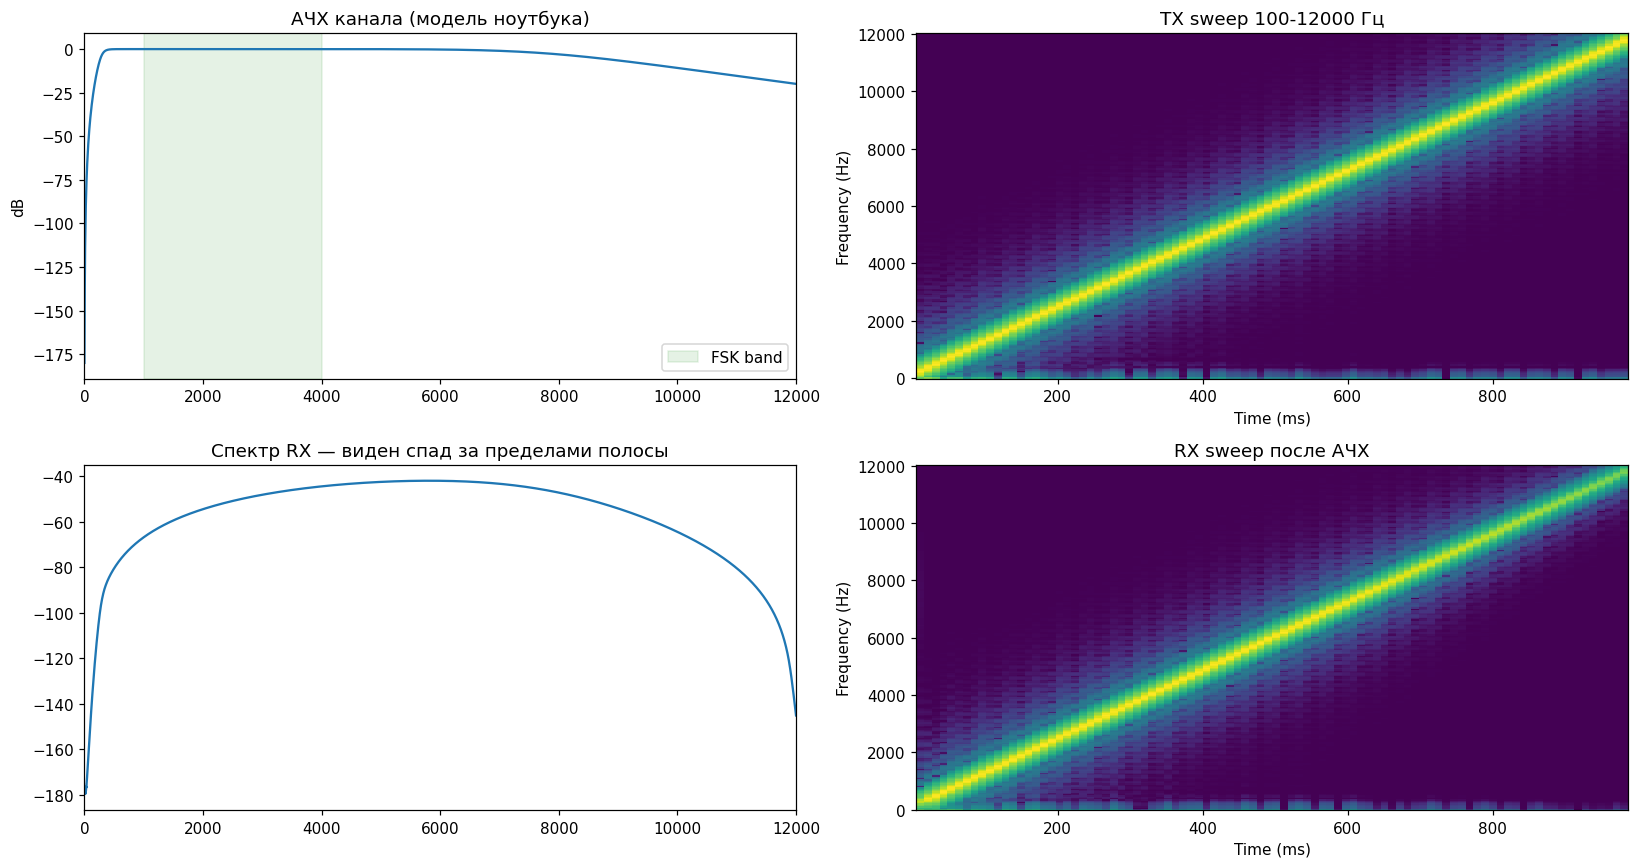

Видно: канал пропускает 300-8000 Гц. Рабочая полоса FSK 1000-4000 Гц — в самой плоской части. ✅


In [5]:
# симулируем АЧХ реального ноутбука: bandpass 300-8000 Гц с плавными скатами
sos = sp.butter(4, [300, 8000], btype='band', fs=FS, output='sos')
sweep = m.generate_chirp(100, 12000, 1.0)
rx_sweep = sp.sosfilt(sos, sweep).astype(np.float32)

# АЧХ через спектр свёртки
f, H = sp.freqz(sos[0][:3], sos[0][3:], worN=4096, fs=FS)
# полная АЧХ фильтра
w, H_full = sp.sosfreqz(sos, worN=4096, fs=FS)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes[0,0].plot(w, 20*np.log10(np.abs(H_full)+1e-9)); axes[0,0].set_xlim(0,12000)
axes[0,0].set_title('АЧХ канала (модель ноутбука)'); axes[0,0].set_ylabel('dB'); axes[0,0].axvspan(1000,4000,color='g',alpha=0.1,label='FSK band'); axes[0,0].legend()
m.plot_spectrogram(sweep, ax=axes[0,1], title='TX sweep 100-12000 Гц', fmax=12000)
m.plot_spectrogram(rx_sweep, ax=axes[1,1], title='RX sweep после АЧХ', fmax=12000)
fr, mag = m.fft_spectrum(rx_sweep); axes[1,0].plot(fr, 20*np.log10(mag+1e-9)); axes[1,0].set_xlim(0,12000)
axes[1,0].set_title('Спектр RX — виден спад за пределами полосы')
plt.tight_layout(); plt.show()
print('Видно: канал пропускает 300-8000 Гц. Рабочая полоса FSK 1000-4000 Гц — в самой плоской части. ✅')

## 2.5 Затухание с расстоянием
Интенсивность звука падает как 1/r², амплитуда — как 1/r. Плюс SNR ухудшается. Моделируем 1, 5, 10, 20 м.

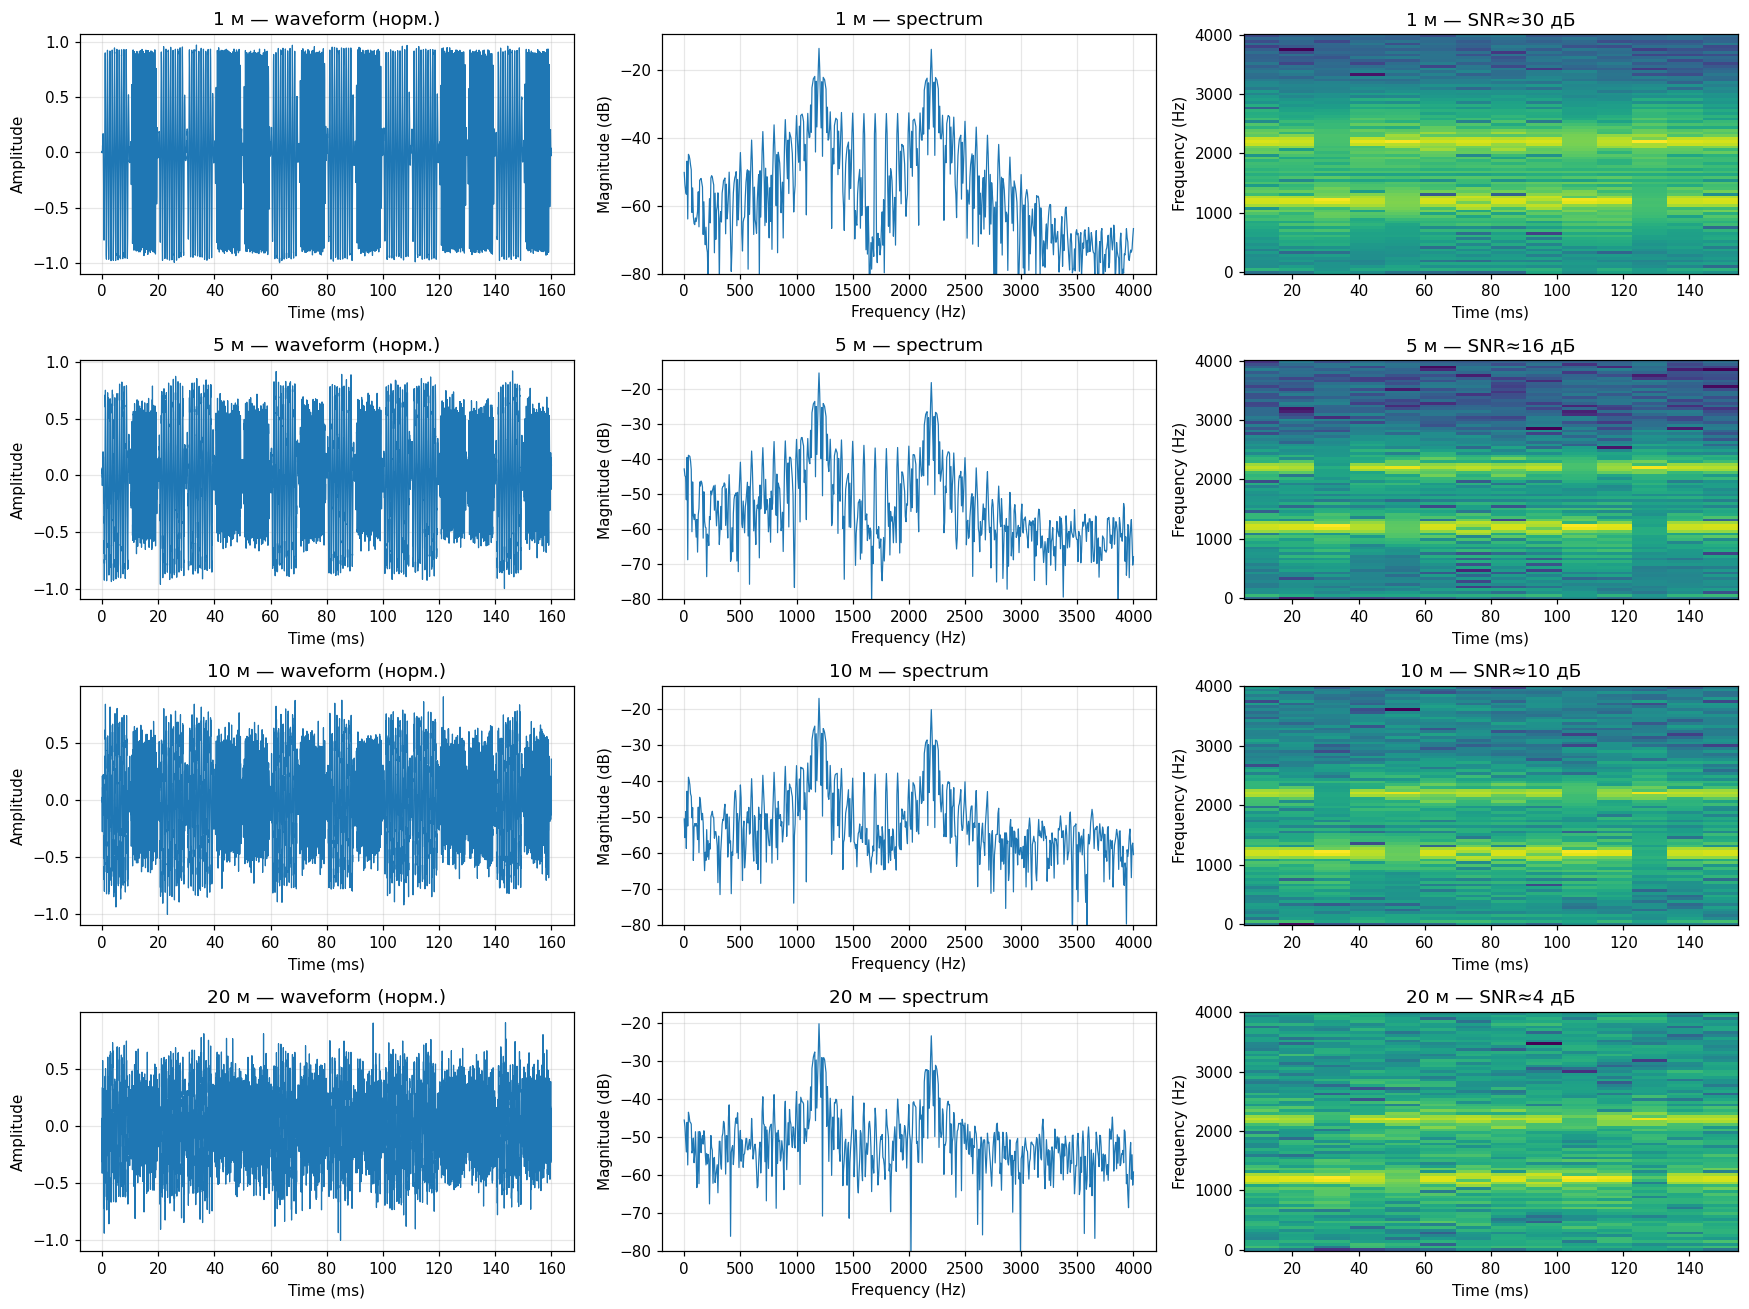

Расст.  SNR,дБ      BER   conf
    1 м    30.0   0.0000   1.00
    5 м    16.0   0.0000   1.00
   10 м    10.0   0.0000   1.00
   20 м     4.0   0.0000   0.99


In [6]:
test_sig = m.generate_fsk('1011001010110010', mark_freq=1200, space_freq=2200, baud_rate=100)
distances = [1, 5, 10, 20]
fig, axes = plt.subplots(len(distances), 3, figsize=(16, 12))
results = []
for i, d in enumerate(distances):
    att = 1.0/d  # амплитуда ~ 1/r
    snr = 30 - 20*np.log10(d)  # SNR падает
    rx = m.simulate_channel(test_sig, snr_db=snr, attenuation=att, reverb_amount=min(0.3, 0.05*d), seed=i)
    # нормируем для отображения
    disp = rx/ (np.max(np.abs(rx))+1e-9)
    m.plot_waveform(disp, ax=axes[i,0], title=f'{d} м — waveform (норм.)', max_duration=0.16)
    m.plot_spectrum(disp, ax=axes[i,1], title=f'{d} м — spectrum', fmax=4000)
    m.plot_spectrogram(disp, ax=axes[i,2], title=f'{d} м — SNR≈{snr:.0f} дБ', fmax=4000)
    # попытка демодуляции
    bits, conf = m.fsk_demodulate(rx, baud_rate=100)
    ber = m.ber_measure('1011001010110010', bits)
    results.append((d, snr, ber['ber'], conf.mean()))
    results_data = results
plt.tight_layout(); plt.show()

print(f"{'Расст.':>6} {'SNR,дБ':>7} {'BER':>8} {'conf':>6}")
for d, snr, ber, cf in results:
    print(f'{d:>5} м {snr:>7.1f} {ber:>8.4f} {cf:>6.2f}')

## 2.6 📊 ИТОГ: рабочие пределы канала
Сводный график: SNR и BER vs расстояние → определяет выбор режима модема.

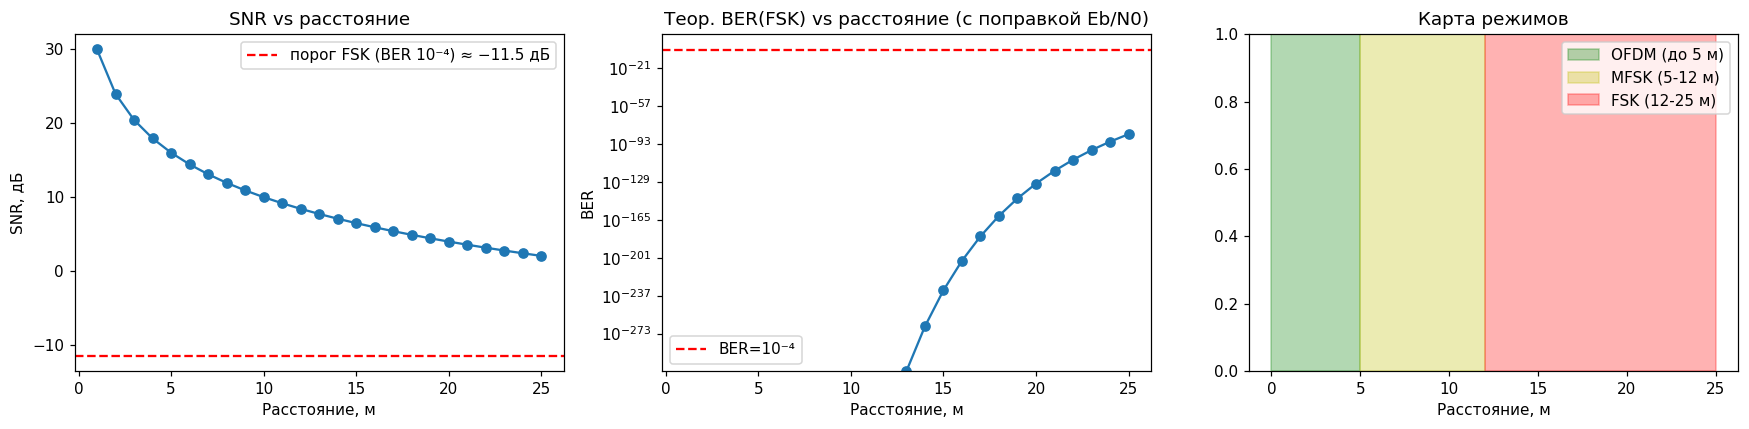

Карта режимов готова — это основа адаптивного выбора в Lab 6.


In [7]:
distances_fine = np.linspace(1, 25, 25)
snr_curve = 30 - 20*np.log10(distances_fine)
# ВАЖНО: theoretical_ber_fsk ждёт Eb/N0, а наша SNR — по ПОЛНОЙ полосе fs/2.
# Goertzel-детектор накопляет энергию за символ (полоса ~ baud=100 Гц):
# Eb/N0 = SNR_full + 10*log10((fs/2)/baud) = SNR_full + 23.8 дБ
EB_N0_CORR_DB = 10*np.log10((FS/2)/100.0)
ber_curve = [m.theoretical_ber_fsk(s + EB_N0_CORR_DB) for s in snr_curve]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(distances_fine, snr_curve, 'o-'); axes[0].axhline(-11.5, color='r', ls='--', label='порог FSK (BER 10⁻⁴) ≈ −11.5 дБ')
axes[0].set_xlabel('Расстояние, м'); axes[0].set_ylabel('SNR, дБ'); axes[0].set_title('SNR vs расстояние'); axes[0].legend()
axes[1].semilogy(distances_fine, ber_curve, 'o-'); axes[1].axhline(1e-4, color='r', ls='--', label='BER=10⁻⁴')
axes[1].set_xlabel('Расстояние, м'); axes[1].set_ylabel('BER'); axes[1].set_title('Теор. BER(FSK) vs расстояние (с поправкой Eb/N0)'); axes[1].legend()
# зоны режимов
axes[2].fill_between([0,5],0,1,color='g',alpha=0.3,label='OFDM (до 5 м)')
axes[2].fill_between([5,12],0,1,color='y',alpha=0.3,label='MFSK (5-12 м)')
axes[2].fill_between([12,25],0,1,color='r',alpha=0.3,label='FSK (12-25 м)')
axes[2].set_xlabel('Расстояние, м'); axes[2].set_title('Карта режимов'); axes[2].legend(); axes[2].set_ylim(0,1)
plt.tight_layout(); plt.show()
print('Карта режимов готова — это основа адаптивного выбора в Lab 6.')

## ✅ Выводы Lab 2

1. **Задержка канала измеряется chirp-корреляцией с точностью ±1 сэмпл** — используем для синхронизации.
2. **Комнатный шум** = розовый + гул 50 Гц. Наша полоса 1-4 кГц выше гула — хорошо.
3. **Многолучёвость** даёт эхо до ~23 мс → либо длинные символы (FSK 10-20 мс — на грани), либо CP в OFDM.
4. **АЧХ ноутбука** полосовая 300-8000 Гц. FSK-полоса 1-4 кГц в плоской части. ✅
5. **SNR падает ~20 дБ на декаду расстояния** (1/r² для энергии).
6. **Порог FSK по BER=10⁻⁴**: Eb/N0 = 12.3 дБ → **полнополосный SNR ≈ −11.5 дБ** (детектор сужает полосу шума до ~100 Гц, +23.8 дБ выигрыша). По модели 20 дБ/декаду это дальность ≫ 25 м — практический предел задаст микрофон, а не BER (проверим в Lab 3).
7. **Карта режимов**: OFDM до 5 м, MFSK 5-12 м, FSK 12-25 м — основа адаптивности.

**Параметры протокола**: `fs=48000`, полоса FSK 1000-4000 Гц, символ 10 мс, FSK теоретически работоспособен до SNR ≈ −11.5 дБ.